# Final Project - Wind Turbine Fault Detection

This notebook presents the complete end-to-end workflow for the Wind Turbine Fault Detection project using multivariate SCADA time-series data. The objective is to predict whether a turbine is approaching a failure event within a future prediction horizon of 24, 48, or 72 hours.

The dataset used in this notebook is the publicly available *Wind Turbine SCADA Data for Early Fault Detection* dataset published through Zenodo (Kasimov, 2024).

The written final report summarizes the motivation, methodology, and interpretation. This notebook complements that report by showing the executable pipeline: project setup, data validation, preprocessing, feature harmonization, labeling, model training, evaluation, and report-ready visual outputs.

Although the project was developed as a modular Python package, the course submission requires a single notebook. For that reason, this notebook acts as a reproducible driver that calls the project package while still exposing every major analytical step.

To run this notebook from a fresh project directory, the repository should include the project package under `src/`, the project configuration file at `config/feature_map.yaml`, and the raw Zenodo dataset extracted under `data/raw/zenodo_windfarm_data/`.

Ideally, you would clone the entire project directory from https://github.com/cneiderer/ML_Project. At minimum, the project directory should be organized with the following structure to execute the notebook:

```bash
ML_Project/
├── config/
│   └── feature_map.yaml
├── data/
│   └── raw/
│       └── zenodo_windfarm_data/
│           ├── Wind Farm A/
│           ├── Wind Farm B/
│           └── Wind Farm C/
├── notebooks/
│   └── neiderer.Milestone3_FinalProjectNotebook.ipynb
└── src/
    └── wtfd/
        └── ...
```

The notebook automatically creates processed-data, artifact, output, diagnostic, and report-figure directories as needed. Dependency information is provided in the project-level `pyproject.toml` and/or `requirements.txt` files when running from the full repository.

## How this notebook is organized

The notebook follows the same analytical sequence as the final report:

1. Configure the project environment and reusable notebook controls.
2. Validate the expected repository inputs and output directories.
3. Run or reuse turbine-level preprocessing artifacts.
4. Inspect the processed dataset and feature schema.
5. Explain the event-based labeling strategy.
6. Train or reuse models for the 24h, 48h, and 72h prediction horizons.
7. Evaluate model performance using precision, recall, F1, threshold behavior, temporal predictions, and feature importance.
8. Save the final figures and table exports used in the written report.

The notebook is designed to run top-to-bottom. Runtime flags are provided so the full pipeline can be rebuilt when needed, while cached artifacts can be reused during normal review or submission testing.


In [1]:
# Optional notebook convenience magics.
# These can be commented out if your environment does not support IPython magics.
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import gc
import json
import sys
from pathlib import Path
from typing import Any, Optional

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import PercentFormatter


In [3]:
def find_project_root(start: Optional[Path] = None) -> Path:
    """Walk upward until a repository root is found."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from within the ML_Project repository."
    )

PROJECT_ROOT = find_project_root()
SRC_ROOT = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Source root:  {SRC_ROOT}")


Project root: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy
Source root:  /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/src


In [4]:
# Optional editable install for environments where the package has not been installed yet.
# Set to True only if imports fail below and you want the notebook to install the local package.
ENABLE_EDITABLE_INSTALL_IF_NEEDED = False

if ENABLE_EDITABLE_INSTALL_IF_NEEDED:
    import subprocess
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-e", str(PROJECT_ROOT)],
        check=True,
    )


In [5]:
from wtfd.data.preprocessing import WindFarmProcessor
from wtfd.models.artifacts import (
    ensure_run_output_dir,
    load_dataframe_artifact,
    load_json_artifact,
    save_dataframe_artifact,
    save_feature_importance,
    save_model_metrics,
    save_run_metadata,
    save_threshold_sweep,
)
from wtfd.models.experiments import get_experiment_config, list_available_experiments
from wtfd.models.feature_selector import (
    build_feature_matrix,
    summarize_feature_selection,
    validate_no_leakage_columns_in_features,
)
from wtfd.models.metrics import build_threshold_sweep_table
from wtfd.models.model_registry import get_model_config, list_available_models
from wtfd.models.splitter import WindFarmSplitter
from wtfd.models.trainer import WindFaultTrainer
from wtfd.utils.logging_utils import get_logger

logger = get_logger("wtfd.notebooks.final_project")

try:
    import xgboost  # noqa: F401
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
mpl.rcParams.update(mpl.rcParamsDefault)
sns.set_theme(style="white", context="notebook")
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 300

print("Available experiments:", list_available_experiments())
print("Available models:", list_available_models())
print("XGBoost available:", HAS_XGBOOST)



Available experiments: ['pre_24h', 'pre_48h', 'pre_72h']
Available models: ['logistic', 'rf', 'xgboost']
XGBoost available: True


## Notebook controls

The next cell centralizes paths and runtime options. These controls make the notebook reproducible while preventing unnecessary recomputation during repeated runs.

For final submission review, the recommended defaults are to reuse existing preprocessing and modeling artifacts unless the underlying data, labeling configuration, or package code has changed.


In [6]:
# ------------------------------------------------------------------
# Project paths
# ------------------------------------------------------------------
CONFIG_PATH = PROJECT_ROOT / "config" / "feature_map.yaml"
RAW_DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "zenodo_windfarm_data"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MASTER_DATASET_PATH = PROCESSED_DIR / "master_dataset.parquet"
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "modeling"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TIMELINE_DIR = OUTPUT_DIR / "failure_timelines"
REPORT_FIG_DIR = OUTPUT_DIR / "final_report_figures"
REPORT_DIAGNOSTICS_DIR = PROJECT_ROOT / "artifacts" / "report_diagnostics"

# ------------------------------------------------------------------
# Preprocessing controls
# ------------------------------------------------------------------
# NOTE:
# The WTDF preprocessing code supports a pre-window exclusion buffer
# immediately before the earliest 72h positive window and a post-event
# exclusion buffer immediately after the event window ends.
BUFFER_BEFORE_HOURS = 4.0
BUFFER_AFTER_HOURS = 4.0
REBUILD_EVENT_PARQUETS = True
REBUILD_MASTER_DATASET = True

# ------------------------------------------------------------------
# Data inspection controls
# ------------------------------------------------------------------
SAMPLE_N_ROWS = 5000
HARMONIZATION_FEATURE_COUNT = 13
FORCE_REBUILD_HARMONIZATION_CACHE = True
HARMONIZATION_CACHE_PATH = REPORT_DIAGNOSTICS_DIR / "feature_harmonization_overview.csv"

# ------------------------------------------------------------------
# Modeling controls
# ------------------------------------------------------------------
EXPERIMENT_NAMES = ["pre_24h", "pre_48h", "pre_72h"]
MODEL_NAMES_OVERRIDE = None     # e.g. ["logistic", "rf", "xgboost"]
# Memory-aware default: the report needs all three models for the representative
# 72h horizon, but only XGBoost for the 24h/48h horizon comparison. This reduces
# peak memory while preserving every result used in the final report. Set values
# to None to run all configured models for every horizon.
EXPERIMENT_MODEL_OVERRIDES = {
    "pre_24h": ["xgboost"],
    "pre_48h": ["xgboost"],
    "pre_72h": ["logistic", "rf", "xgboost"],
}
NUMERIC_ONLY = True
FEATURE_SUBSET = None
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42
REUSE_SAVED_MODEL_ARTIFACTS = False
SAVE_FRESH_MODELING_ARTIFACTS = True
KEEP_FULL_EXPERIMENT_OBJECTS = False

# ------------------------------------------------------------------
# Report-specific controls
# ------------------------------------------------------------------
REPORT_EXPERIMENT_NAME = "pre_72h"
REPORT_MODEL_NAME = "xgboost"
FORCE_REBUILD_REPORT_DIAGNOSTICS = True
SAVE_REPORT_FIGURES = True
TABLE_DECIMALS = 3

# ------------------------------------------------------------------
# Visualization controls
# ------------------------------------------------------------------
TIMELINE_SIGNALS = [
    "vibration_raw",
    "nacelle_temp",
    "temp_delta_gearbox",
]
TIMELINE_HOURS_BEFORE = 168
TIMELINE_HOURS_AFTER = 24
TOP_N_FEATURES = 15

# Conceptual display only for Figure 1. This is not a data-derived duration.
FIG_1_EVENT_WINDOW_HOURS = 4.0


## Validate required repository inputs

Before any analysis is performed, the notebook verifies that the expected project structure is available. The notebook requires two inputs before execution: the feature mapping file at `config/feature_map.yaml` and the raw SCADA dataset directory at `data/raw/zenodo_windfarm_data/`.

Output directories are created automatically if they do not already exist. The same cell also reports whether key processed artifacts already exist, which determines whether expensive preprocessing steps can be skipped.


In [7]:
required_paths = {
    "config": CONFIG_PATH,
    "raw_data_root": RAW_DATA_ROOT,
    "processed_dir": PROCESSED_DIR,
    "artifact_root": ARTIFACT_ROOT,
    "output_dir": OUTPUT_DIR,
    "report_fig_dir": REPORT_FIG_DIR,
    "report_diagnostics_dir": REPORT_DIAGNOSTICS_DIR,
}

assert CONFIG_PATH.exists(), f"Missing config file: {CONFIG_PATH}"
assert RAW_DATA_ROOT.exists(), f"Missing raw data root: {RAW_DATA_ROOT}"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TIMELINE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

event_parquet_files = sorted(
    [p for p in PROCESSED_DIR.glob("*.parquet") if p.name != "master_dataset.parquet"]
)

for path_name, path_value in required_paths.items():
    print(f"{path_name:>22}: {path_value} | exists={path_value.exists()}")

def processed_dataset_has_excluded_buffer_rows(parquet_files: list[Path]) -> bool:
    """Return True if any processed event parquet contains excluded-buffer rows."""
    for parquet_path in parquet_files:
        try:
            buffer_df = pd.read_parquet(parquet_path, columns=["is_excluded_buffer"])
            if "is_excluded_buffer" in buffer_df.columns and buffer_df["is_excluded_buffer"].fillna(False).any():
                return True
        except Exception:
            try:
                state_df = pd.read_parquet(parquet_path, columns=["state_name"])
                if "state_name" in state_df.columns and state_df["state_name"].astype(str).eq("excluded_buffer").any():
                    return True
            except Exception:
                continue
    return False


existing_buffer_rows_present = (
    processed_dataset_has_excluded_buffer_rows(event_parquet_files)
    if event_parquet_files
    else False
)

repo_summary_df = pd.DataFrame(
    [
        {"item": "event parquet files", "count": len(event_parquet_files)},
        {"item": "master dataset exists", "count": int(MASTER_DATASET_PATH.exists())},
        {"item": "artifact experiment folders", "count": sum(1 for p in ARTIFACT_ROOT.glob("*") if p.is_dir())},
        {"item": "report figure directory", "count": int(REPORT_FIG_DIR.exists())},
        {"item": "existing excluded_buffer rows detected", "count": int(existing_buffer_rows_present)},
    ]
)
display(repo_summary_df)

if event_parquet_files and (BUFFER_BEFORE_HOURS > 0 or BUFFER_AFTER_HOURS > 0) and not existing_buffer_rows_present:
    print(
        "Configured notebook uses nonzero exclusion buffers, but the existing processed "
        "event parquet files contain no excluded_buffer rows. Forcing a preprocessing "
        "rebuild so the notebook, figure logic, and underlying labels stay aligned."
    )
    REBUILD_EVENT_PARQUETS = True
    REBUILD_MASTER_DATASET = True
    REUSE_SAVED_MODEL_ARTIFACTS = False
    FORCE_REBUILD_REPORT_DIAGNOSTICS = True

print()
print(f"BUFFER_BEFORE_HOURS = {BUFFER_BEFORE_HOURS}")
print(f"BUFFER_AFTER_HOURS  = {BUFFER_AFTER_HOURS}")
print(f"REBUILD_EVENT_PARQUETS = {REBUILD_EVENT_PARQUETS}")
print(f"REBUILD_MASTER_DATASET = {REBUILD_MASTER_DATASET}")
print(f"REUSE_SAVED_MODEL_ARTIFACTS = {REUSE_SAVED_MODEL_ARTIFACTS}")
print(f"FORCE_REBUILD_REPORT_DIAGNOSTICS = {FORCE_REBUILD_REPORT_DIAGNOSTICS}")

                config: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/config/feature_map.yaml | exists=True
         raw_data_root: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/data/raw/zenodo_windfarm_data | exists=True
         processed_dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/data/processed | exists=True
         artifact_root: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/artifacts/modeling | exists=True
            output_dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs | exists=True
        report_fig_dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures | exists=True
report_diagnostics_dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/artifacts/report_diagnostics | exists=True


,item,count
0,event parquet files,95
1,master dataset exists,1
2,artifact experiment folders,3
3,report figure directory,1
4,existing excluded_buffer rows detected,1



BUFFER_BEFORE_HOURS = 4.0
BUFFER_AFTER_HOURS  = 4.0
REBUILD_EVENT_PARQUETS = True
REBUILD_MASTER_DATASET = True
REUSE_SAVED_MODEL_ARTIFACTS = False
FORCE_REBUILD_REPORT_DIAGNOSTICS = True


## Methodology summary

### Data processing strategy
Raw SCADA files are processed at the turbine/event level to preserve chronological order and avoid loading the entire raw dataset into memory at once. Farm-specific sensor channels are mapped into a standardized feature space so the same physical concepts can be modeled consistently across farms.

### Feature engineering strategy
The modeling dataset combines standardized sensor signals with physically interpretable temporal features. Rolling statistics, lagged values, volatility measures, rate-of-change features, and efficiency-style metrics are used to represent gradual degradation patterns rather than isolated sensor snapshots.

### Labeling strategy
Each timestamp is labeled according to whether a failure occurs within a future prediction horizon. The project evaluates 24h, 48h, and 72h horizons. Buffer zones are used to remove ambiguous observations near event boundaries and reduce leakage between normal and pre-failure behavior.

### Modeling strategy
Three supervised classifiers are evaluated: Logistic Regression as an interpretable baseline, Random Forest as a nonlinear ensemble baseline, and XGBoost as the primary gradient-boosted tree model. Performance is assessed with precision, recall, and F1 because accuracy is not meaningful under severe class imbalance.


## Initialize the preprocessing pipeline

The `WindFarmProcessor` is responsible for reading the feature map, harmonizing farm-specific sensor names, engineering derived features, assigning event-based labels, and writing processed Parquet outputs.

The processor is initialized with explicit buffer settings so the notebook reflects the labeling design described in the report.


In [8]:
processor = WindFarmProcessor(
    config_path=CONFIG_PATH,
    buffer_before_hours=BUFFER_BEFORE_HOURS,
    buffer_after_hours=BUFFER_AFTER_HOURS,
)

processor

2026-04-15 16:52:25 | INFO | wtfd.data.preprocessing | Initialized WindFarmProcessor with config_path=/mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/config/feature_map.yaml, buffer_before_hours=4.0, buffer_after_hours=4.0


## Run preprocessing only when needed

The full preprocessing step can be expensive, so this notebook first checks whether event-level Parquet files and the consolidated master dataset already exist. If those artifacts are present and the rebuild flags are disabled, the notebook reuses them.

This approach keeps the submission notebook practical to rerun while still including the full preprocessing code path required for reproducibility.


In [9]:
if REBUILD_EVENT_PARQUETS or not event_parquet_files:
    logger.info("Running event-level preprocessing.")
    processor.process_all_turbines(
        raw_data_root=RAW_DATA_ROOT,
        output_dir=PROCESSED_DIR,
    )
    event_parquet_files = sorted(
        [p for p in PROCESSED_DIR.glob("*.parquet") if p.name != "master_dataset.parquet"]
    )
else:
    logger.info("Reusing existing event-level parquet files.")
    print(f"Reusing {len(event_parquet_files)} event-level parquet files from {PROCESSED_DIR}")

if REBUILD_MASTER_DATASET or not MASTER_DATASET_PATH.exists():
    if not event_parquet_files:
        raise FileNotFoundError(
            "No event-level parquet files are available, so the master dataset cannot be built."
        )
    logger.info("Building consolidated master dataset.")
    master_dataset_output = processor.create_master_dataset(
        processed_dir=PROCESSED_DIR,
        output_path=MASTER_DATASET_PATH,
    )
    print(f"Master dataset created: {master_dataset_output}")
else:
    logger.info("Reusing existing master dataset.")
    print(f"Reusing existing master dataset: {MASTER_DATASET_PATH}")

assert MASTER_DATASET_PATH.exists(), f"Master dataset not found: {MASTER_DATASET_PATH}"


2026-04-15 16:52:25 | INFO | wtfd.notebooks.final_project | Running event-level preprocessing.
2026-04-15 16:52:25 | INFO | wtfd.data.preprocessing | Beginning batch preprocessing from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/data/raw/zenodo_windfarm_data to /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/data/processed
2026-04-15 16:52:25 | INFO | wtfd.data.preprocessing | Found 22 raw files for farm A
Farm A:   0%|                                                                                    | 0/22 [00:00<?, ?it/s]2026-04-15 16:52:25 | INFO | wtfd.data.preprocessing | Starting pipeline for farm_id=A, file=0.csv
2026-04-15 16:52:26 | INFO | wtfd.data.preprocessing | Completed pipeline for farm_id=A, file=0.csv, output_shape=(54986, 46)
2026-04-15 16:52:26 | INFO | wtfd.data.preprocessing | Saved processed file: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/data/processed/A_event_0.parquet
Farm A:   5%|█

Master dataset created: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/data/processed/master_dataset.parquet


## Review generated preprocessing artifacts

The event-level Parquet files preserve the turbine/event granularity used during preprocessing. The consolidated master dataset is then used for modeling, evaluation, and report figures.

This inspection step confirms that the expected artifacts were created and gives a quick view of the processed data footprint.


In [10]:
event_file_summary = pd.DataFrame(
    {
        "file_name": [p.name for p in event_parquet_files],
        "size_mb": [round(p.stat().st_size / (1024 ** 2), 3) for p in event_parquet_files],
    }
).sort_values("file_name").reset_index(drop=True)

display(event_file_summary.head(10))

master_parquet = pq.ParquetFile(MASTER_DATASET_PATH)
print(f"Master dataset row groups: {master_parquet.num_row_groups}")
print("Master dataset schema:")
print(master_parquet.schema)


,file_name,size_mb
0,A_event_0.parquet,7.362
1,A_event_10.parquet,7.208
2,A_event_13.parquet,7.201
3,A_event_14.parquet,7.330
4,A_event_17.parquet,7.416
5,A_event_22.parquet,7.061
6,A_event_24.parquet,7.407
7,A_event_25.parquet,7.373
8,A_event_26.parquet,7.203
9,A_event_3.parquet,7.455


Master dataset row groups: 96
Master dataset schema:
required group field_id=-1 schema {
  optional int64 field_id=-1 time_stamp (Timestamp(isAdjustedToUTC=false, timeUnit=nanoseconds, is_from_converted_type=false, force_set_converted_type=false));
  optional binary field_id=-1 farm_id (String);
  optional binary field_id=-1 asset_id (String);
  optional double field_id=-1 amb_temp;
  optional double field_id=-1 wind_speed;
  optional double field_id=-1 pitch_angle;
  optional double field_id=-1 active_power;
  optional double field_id=-1 gen_speed;
  optional double field_id=-1 gearbox_oil_temp;
  optional double field_id=-1 transformer_temp;
  optional double field_id=-1 nacelle_temp;
  optional double field_id=-1 hub_temp;
  optional double field_id=-1 yaw_error;
  optional double field_id=-1 vibration_raw;
  optional double field_id=-1 hydraulic_temp;
  optional double field_id=-1 generator_temp;
  optional double field_id=-1 temp_delta_gearbox;
  optional double field_id=-1 temp_t

## Load a sample for exploratory inspection

A small sample is loaded from the master Parquet file for fast schema checks. This is not used for model fitting; it is only a lightweight diagnostic to verify that labels and engineered features are present before the full dataset is loaded later.


In [11]:
sample_batches = []
rows_loaded = 0

for batch in master_parquet.iter_batches(batch_size=SAMPLE_N_ROWS):
    sample_batches.append(batch)
    rows_loaded += batch.num_rows
    if rows_loaded >= SAMPLE_N_ROWS:
        break

sample_df = pa.Table.from_batches(sample_batches).slice(0, SAMPLE_N_ROWS).to_pandas()

print(f"Loaded {len(sample_df):,} sample rows from {MASTER_DATASET_PATH.name}")
display(sample_df.head())
print()
sample_df.info()


Loaded 5,000 sample rows from master_dataset.parquet


,time_stamp,farm_id,asset_id,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,vibration_raw,hydraulic_temp,generator_temp,temp_delta_gearbox,temp_trend_24h,rpm_volatility,temp_divergence,power_efficiency,vibration_magnitude,gearbox_oil_temp_delta_6,gearbox_oil_temp_volatility_6,gearbox_oil_temp_delta_24,gearbox_oil_temp_volatility_24,generator_temp_delta_6,generator_temp_volatility_6,generator_temp_delta_24,generator_temp_volatility_24,active_power_delta_6,active_power_volatility_6,active_power_delta_24,active_power_volatility_24,yaw_error_delta_6,yaw_error_volatility_6,yaw_error_delta_24,yaw_error_volatility_24,event_id,event_label,event_start,event_end,state_label,state_name,is_excluded_buffer,target
0,2022-08-04 06:10:00,A,0,22.0,1.7,24.0,-2.560,35.3,41.0,66.333333,30.0,31.0,129.4,22.1,41.0,31.5,19.0,0.0,0.0,-1.0,-0.521067,22.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
1,2022-08-04 06:20:00,A,0,22.0,1.7,24.0,-2.556,0.0,41.0,66.333333,30.0,31.0,133.6,0.0,41.0,31.5,19.0,0.0,0.0,-1.0,-0.520252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
2,2022-08-04 06:30:00,A,0,22.0,0.9,24.0,-2.712,2.8,41.0,66.333333,30.0,31.0,167.1,5.8,41.0,31.5,19.0,0.0,0.0,-1.0,-3.720165,5.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
3,2022-08-04 06:40:00,A,0,22.0,1.5,24.0,-2.548,0.4,41.0,66.000000,29.0,30.0,-49.1,1.9,41.0,31.5,19.0,0.0,0.0,-1.0,-0.754963,1.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
4,2022-08-04 06:50:00,A,0,22.0,1.0,24.0,-2.568,0.0,41.0,65.666667,29.0,30.0,-107.3,0.0,41.0,30.5,19.0,0.0,0.0,-1.0,-2.568000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   time_stamp                      5000 non-null   datetime64[ns]
 1   farm_id                         5000 non-null   object        
 2   asset_id                        5000 non-null   object        
 3   amb_temp                        5000 non-null   float64       
 4   wind_speed                      5000 non-null   float64       
 5   pitch_angle                     5000 non-null   float64       
 6   active_power                    5000 non-null   float64       
 7   gen_speed                       5000 non-null   float64       
 8   gearbox_oil_temp                5000 non-null   float64       
 9   transformer_temp                5000 non-null   float64       
 10  nacelle_temp                    5000 non-null   float64       
 11  hub

## Basic sample sanity checks

These checks verify that the processed sample includes the expected labeling columns and standardized or derived feature columns. They provide a quick validation step before the notebook moves into full-dataset analysis.


In [12]:
required_label_columns = ["state_label", "state_name", "target"]
present_label_columns = [c for c in required_label_columns if c in sample_df.columns]

print("Present label columns:", present_label_columns)

expected_features = set(processor.standard_features) | set(processor.config.get("derived_features", []))
present_expected_features = sorted(expected_features & set(sample_df.columns))
missing_expected_features = sorted(expected_features - set(sample_df.columns))

schema_check_df = pd.DataFrame(
    [
        {
            "n_sample_rows": len(sample_df),
            "n_columns": sample_df.shape[1],
            "n_present_expected_features": len(present_expected_features),
            "n_missing_expected_features": len(missing_expected_features),
        }
    ]
)
display(schema_check_df)

if missing_expected_features:
    print("Missing expected features:")
    print(missing_expected_features[:50])
else:
    print("All expected mapped/derived features are present in the sample.")


Present label columns: ['state_label', 'state_name', 'target']


,n_sample_rows,n_columns,n_present_expected_features,n_missing_expected_features
0,5000,46,19,0


All expected mapped/derived features are present in the sample.


## Figure 1: Labeling Strategy Timeline Diagram

This conceptual figure explains how timestamps are labeled relative to failure onset. The main idea is that each model predicts whether a failure occurs within its corresponding future window: 24h, 48h, or 72h.

The figure also shows the pre-event and post-event buffer zones used to remove ambiguous transition periods. This supports the report's discussion of event-based labeling and helps distinguish the prediction task from exact failure-time forecasting.


Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_1_labeling_strategy.png


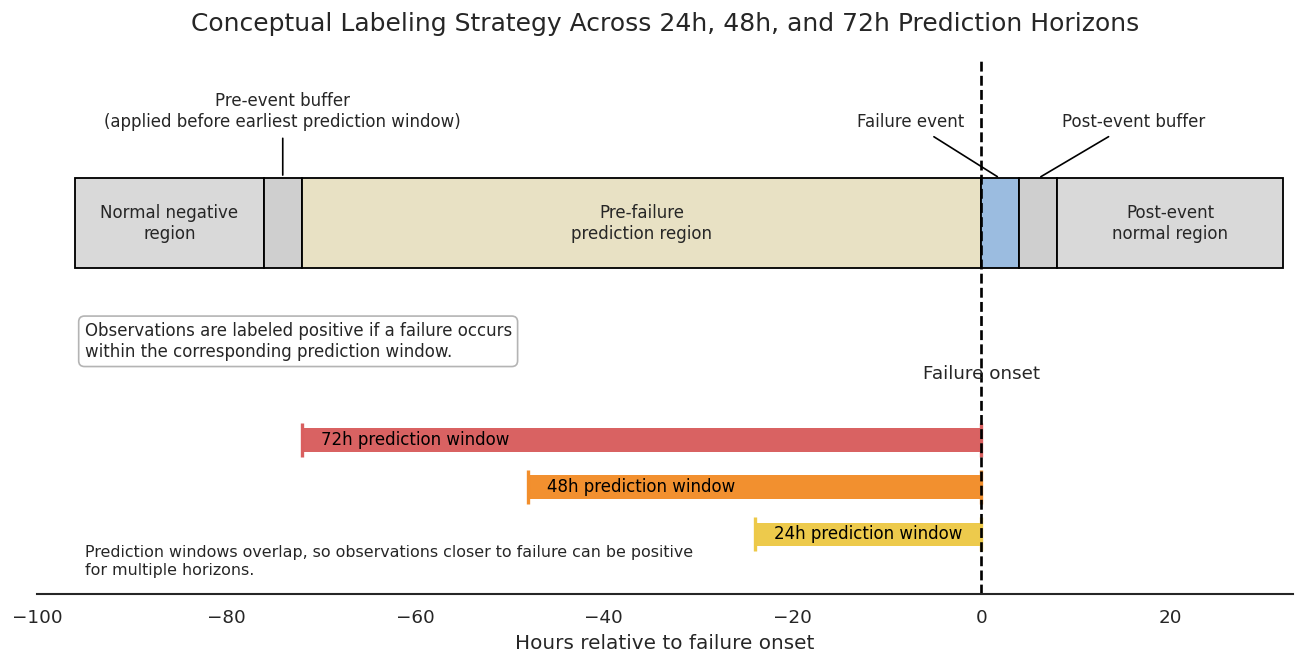

In [13]:
# ------------------------------------------------------------------
# Shared helpers for report figures and tables
# ------------------------------------------------------------------
def prettify_model_name(model_name: str) -> str:
    mapping = {
        "logistic": "Logistic Regression",
        "rf": "Random Forest",
        "random_forest": "Random Forest",
        "xgboost": "XGBoost",
    }
    return mapping.get(str(model_name), str(model_name))


def prettify_experiment_name(experiment_name: str) -> str:
    mapping = {
        "pre_24h": "24h",
        "pre_48h": "48h",
        "pre_72h": "72h",
    }
    return mapping.get(str(experiment_name), str(experiment_name))


def clean_feature_name(feature_name: str) -> str:
    return str(feature_name).replace("_", " ").title()


def save_table_figure(
    df: pd.DataFrame,
    title: str,
    output_path: Path,
    decimals: int = TABLE_DECIMALS,
    index: bool = False,
    figsize: Optional[tuple[float, float]] = None,
) -> None:
    """Render a compact DataFrame as a PNG figure for report insertion."""
    df_to_plot = df.copy()
    numeric_cols = df_to_plot.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        df_to_plot[numeric_cols] = df_to_plot[numeric_cols].round(decimals)

    if not index:
        df_to_plot = df_to_plot.reset_index(drop=True)

    n_rows, n_cols = df_to_plot.shape
    if figsize is None:
        fig_width = max(7.5, 2.05 * n_cols)
        fig_height = max(1.9, 0.42 * (n_rows + 1) + 0.85)
        figsize = (fig_width, fig_height)

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=df_to_plot.values,
        colLabels=df_to_plot.columns,
        loc="center",
        cellLoc="center",
        bbox=[0.01, 0.10, 0.98, 0.76],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.22)

    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(1.2)
        if row == 0:
            cell.set_text_props(weight="normal")

    ax.set_title(title, fontsize=12, pad=1)
    fig.subplots_adjust(top=0.82, bottom=0.06, left=0.03, right=0.97)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.03)
    plt.show()
    plt.close(fig)
    print(f"Saved table figure to: {output_path}")


def save_dataframe_csv(df: pd.DataFrame, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path, index=False)
    print(f"Saved table data to: {output_path}")


def get_result_row(results_df: pd.DataFrame, model_name: str) -> pd.Series:
    matches = results_df.loc[results_df["model_name"] == model_name]
    if matches.empty:
        raise KeyError(f"Model '{model_name}' was not found in the supplied results.")
    return matches.iloc[0]


report_asset_records: list[dict[str, str]] = []


def has_direct_mapping(mapping_value: Any) -> bool:
    """Return True when a farm has a usable direct mapping for a standardized feature."""
    if mapping_value is None:
        return False
    if isinstance(mapping_value, (list, tuple, set)):
        return any(v not in (None, "") for v in mapping_value)
    return mapping_value != ""


# ------------------------------------------------------------------
# Figure 1: conceptual labeling strategy
# ------------------------------------------------------------------
fig_1_path = REPORT_FIG_DIR / "fig_1_labeling_strategy.png"

pre_buffer_start = -72 - BUFFER_BEFORE_HOURS
event_display_end = FIG_1_EVENT_WINDOW_HOURS
post_buffer_end = event_display_end + BUFFER_AFTER_HOURS

context_segments = [
    (-96, pre_buffer_start, "Normal negative\nregion", "#D9D9D9", True),
    (pre_buffer_start, -72, "", "#CFCFCF", False),
    (-72, 0, "Pre-failure\nprediction region", "#E8E1C4", True),
    (0, event_display_end, "", "#9BBCE0", False),
    (event_display_end, post_buffer_end, "", "#CFCFCF", False),
    (post_buffer_end, 32, "Post-event\nnormal region", "#D9D9D9", True),
]

window_rows = [
    ("72h prediction window", -72, 0, 0.27, "#D95F5F"),
    ("48h prediction window", -48, 0, 0.18, "#F28E2B"),
    ("24h prediction window", -24, 0, 0.09, "#EDC948"),
]

fig, ax = plt.subplots(figsize=(13.5, 5.8))

# Top context timeline
context_y = 0.62
context_height = 0.17
for start, end, label, color, show_label in context_segments:
    ax.add_patch(
        Rectangle(
            (start, context_y),
            end - start,
            context_height,
            facecolor=color,
            edgecolor="black",
            linewidth=1.1,
        )
    )
    if show_label:
        ax.text(
            (start + end) / 2,
            context_y + context_height / 2,
            label,
            ha="center",
            va="center",
            fontsize=10,
        )

# Region annotations above the timeline for narrow segments
annotation_style = dict(arrowstyle="-", linewidth=1.0, color="black")
ax.annotate(
    "Pre-event buffer\n(applied before earliest prediction window)",
    xy=((pre_buffer_start - 72) / 2, context_y + context_height),
    xytext=((pre_buffer_start - 72) / 2, 0.88),
    ha="center",
    va="bottom",
    fontsize=10,
    arrowprops=annotation_style,
)
ax.annotate(
    "Failure event",
    xy=(event_display_end / 2, context_y + context_height),
    xytext=(-1.8, 0.88),
    ha="right",
    va="bottom",
    fontsize=10,
    arrowprops=annotation_style,
)
ax.annotate(
    "Post-event buffer",
    xy=((event_display_end + post_buffer_end) / 2, context_y + context_height),
    xytext=(8.5, 0.88),
    ha="left",
    va="bottom",
    fontsize=10,
    arrowprops=annotation_style,
)

# Bottom model windows
window_height = 0.045
for label, start, end, y, color in window_rows:
    ax.add_patch(
        Rectangle(
            (start, y),
            end - start,
            window_height,
            facecolor=color,
            edgecolor=color,
            linewidth=0,
            alpha=0.98,
        )
    )
    ax.vlines([start, end], y - 0.01, y + window_height + 0.01, colors=color, linewidth=2)
    ax.text(
        start + 2,
        y + window_height / 2,
        label,
        ha="left",
        va="center",
        fontsize=10,
        color="black",
    )

# Failure onset
ax.axvline(0, color="black", linestyle="--", linewidth=1.6)
ax.text(0, 0.40, "Failure onset", ha="center", va="bottom", fontsize=11)

# Explanatory annotations
annotation_box = dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#B0B0B0", alpha=0.95)
ax.text(
    -95,
    0.48,
    "Observations are labeled positive if a failure occurs\nwithin the corresponding prediction window.",
    ha="left",
    va="center",
    fontsize=10,
    bbox=annotation_box,
)
ax.text(
    -95,
    0.03,
    "Prediction windows overlap, so observations closer to failure can be positive\nfor multiple horizons.",
    ha="left",
    va="bottom",
    fontsize=9.5,
)

ax.set_xlim(-100, 33)
ax.set_ylim(0, 1.02)
ax.set_yticks([])
ax.set_xlabel("Hours relative to failure onset")
ax.set_title(
    "Conceptual Labeling Strategy Across 24h, 48h, and 72h Prediction Horizons",
    fontsize=15,
    pad=16,
)
ax.spines[["left", "right", "top"]].set_visible(False)

if SAVE_REPORT_FIGURES:
    fig.savefig(fig_1_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 1", "path": str(fig_1_path)})
    print(f"Saved figure to: {fig_1_path}")

plt.show()
plt.close(fig)

## Load the full processed dataset for consolidated analysis

The full master dataset is loaded after the lightweight schema checks. This dataset is used for class-balance analysis, experiment construction, model evaluation, and the report-aligned figures.


In [14]:
def optimize_master_dataframe_memory(df: pd.DataFrame) -> pd.DataFrame:
    """Reduce in-memory footprint of the master dataset for notebook execution."""
    df = df.copy()

    # Downcast continuous SCADA features from float64 to float32. This roughly
    # halves memory for numeric columns and is sufficient precision for modeling.
    float_cols = df.select_dtypes(include=["float64"]).columns
    for col in float_cols:
        df[col] = df[col].astype("float32")

    # Downcast integer columns where possible.
    int_cols = df.select_dtypes(include=["int64"]).columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    # Store repeated labels/IDs as categoricals instead of Python objects.
    object_cols = df.select_dtypes(include=["object"]).columns
    for col in object_cols:
        unique_ratio = df[col].nunique(dropna=False) / max(len(df), 1)
        if unique_ratio < 0.5:
            df[col] = df[col].astype("category")

    return df


master_df = pd.read_parquet(MASTER_DATASET_PATH)
raw_memory_mb = master_df.memory_usage(deep=True).sum() / (1024 ** 2)
master_df = optimize_master_dataframe_memory(master_df)
optimized_memory_mb = master_df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Master dataset shape: {master_df.shape}")
print(f"Master dataset memory: {raw_memory_mb:,.1f} MB -> {optimized_memory_mb:,.1f} MB")
display(master_df.head(3))


Master dataset shape: (5242948, 46)
Master dataset memory: 2,862.7 MB -> 875.0 MB


,time_stamp,farm_id,asset_id,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,vibration_raw,hydraulic_temp,generator_temp,temp_delta_gearbox,temp_trend_24h,rpm_volatility,temp_divergence,power_efficiency,vibration_magnitude,gearbox_oil_temp_delta_6,gearbox_oil_temp_volatility_6,gearbox_oil_temp_delta_24,gearbox_oil_temp_volatility_24,generator_temp_delta_6,generator_temp_volatility_6,generator_temp_delta_24,generator_temp_volatility_24,active_power_delta_6,active_power_volatility_6,active_power_delta_24,active_power_volatility_24,yaw_error_delta_6,yaw_error_volatility_6,yaw_error_delta_24,yaw_error_volatility_24,event_id,event_label,event_start,event_end,state_label,state_name,is_excluded_buffer,target
0,2022-08-04 06:10:00,A,0,22.0,1.7,24.0,-2.560,35.299999,41.0,66.333336,30.0,31.0,129.399994,22.1,41.0,31.5,19.0,0.0,0.0,-1.0,-0.521067,22.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
1,2022-08-04 06:20:00,A,0,22.0,1.7,24.0,-2.556,0.000000,41.0,66.333336,30.0,31.0,133.600006,0.0,41.0,31.5,19.0,0.0,0.0,-1.0,-0.520252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
2,2022-08-04 06:30:00,A,0,22.0,0.9,24.0,-2.712,2.800000,41.0,66.333336,30.0,31.0,167.100006,5.8,41.0,31.5,19.0,0.0,0.0,-1.0,-3.720165,5.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0


## Figure 2: Cross-Farm Feature Availability and Harmonization Overview

This figure shows the schema problem the pipeline had to solve.

The matrix indicates whether each standardized modeling feature was available directly from a mapped raw sensor, derived from other available signals, or unavailable for a given wind farm. This supports the report's discussion of cross-farm naming inconsistencies, nonuniform sensor availability, and feature harmonization.


,feature,Farm A,Farm B,Farm C
0,Wind Speed,Available,Available,Available
1,Active Power,Available,Available,Available
2,Gen Speed,Available,Available,Available
3,Nacelle Temp,Available,Available,Available
4,Gearbox Oil Temp,Available,Available,Available
5,Generator Temp,Available,Available,Available
6,Hub Temp,Available,Available,Available
7,Hydraulic Temp,Available,Unavailable,Available
8,Vibration Raw,Available,Available,Available
9,Yaw Error,Available,Available,Available


Saved table data to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_2_harmonization_overview.csv


/tmp/ipykernel_805/3077319225.py:81: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_matrix = harmonization_df.set_index("feature").replace(state_to_value)


Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_2_harmonization_overview.png


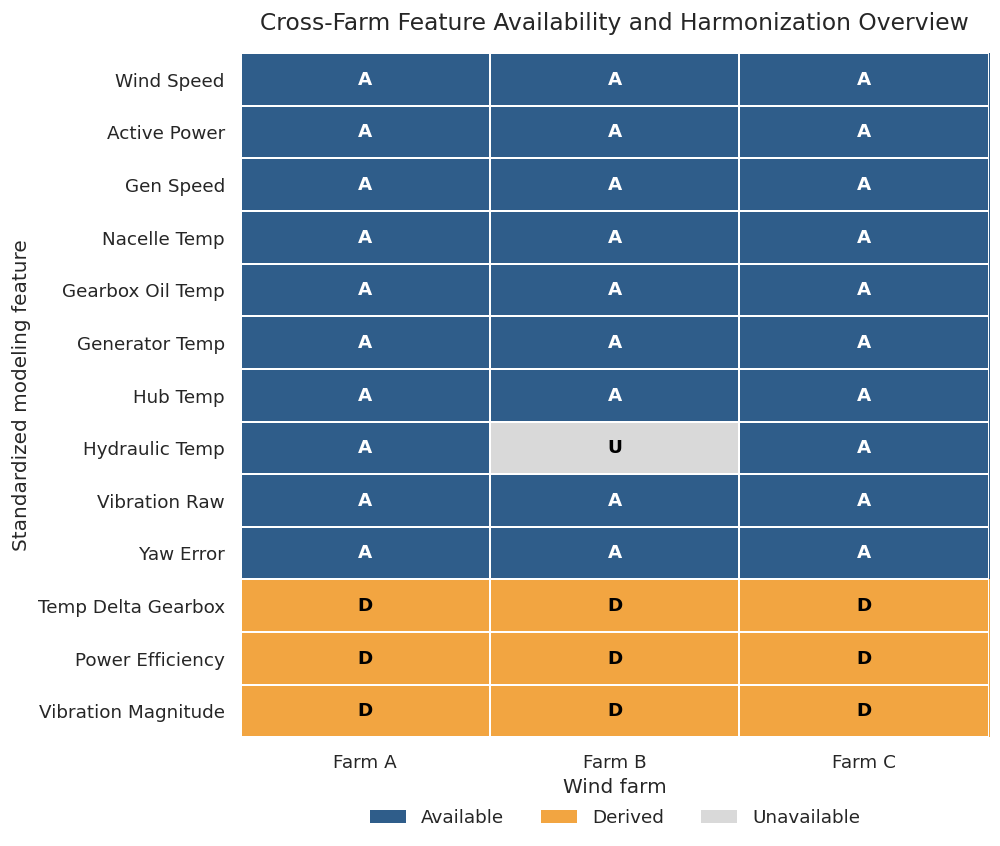

In [15]:
fig_2_path = REPORT_FIG_DIR / "fig_2_harmonization_overview.png"
fig_2_csv_path = REPORT_FIG_DIR / "fig_2_harmonization_overview.csv"

DERIVED_FEATURE_PREREQS = {
    "temp_delta_gearbox": ["gearbox_oil_temp", "amb_temp"],
    "temp_trend_24h": ["gearbox_oil_temp"],
    "rpm_volatility": ["gen_speed"],
    "temp_divergence": ["nacelle_temp", "hub_temp"],
    "power_efficiency": ["wind_speed", "active_power"],
    "vibration_magnitude": ["vibration_raw"],
}

# Keep the report figure focused on the most interpretable features used later in the
# modeling and feature-importance discussion.
HARMONIZATION_FEATURES = [
    "wind_speed",
    "active_power",
    "gen_speed",
    "nacelle_temp",
    "gearbox_oil_temp",
    "generator_temp",
    "hub_temp",
    "hydraulic_temp",
    "vibration_raw",
    "yaw_error",
    "temp_delta_gearbox",
    "power_efficiency",
    "vibration_magnitude",
]


def feature_state_for_farm(feature_name: str, farm_id: str, config: dict[str, Any]) -> str:
    """Classify a standardized feature as Available, Derived, or Unavailable for one farm."""
    farm_sensors = config["farms"][farm_id]["sensors"]

    if feature_name in config.get("standard_features", []):
        return "Available" if has_direct_mapping(farm_sensors.get(feature_name)) else "Unavailable"

    if feature_name in config.get("derived_features", []):
        prereqs = DERIVED_FEATURE_PREREQS.get(feature_name, [])
        if prereqs and all(has_direct_mapping(farm_sensors.get(prereq)) for prereq in prereqs):
            return "Derived"
        return "Unavailable"

    return "Unavailable"


def build_harmonization_overview(
    config: dict[str, Any],
    selected_features: list[str],
) -> pd.DataFrame:
    """Create a feature-by-farm matrix describing harmonization status."""
    records: list[dict[str, str]] = []
    farm_ids = list(config["farms"].keys())

    for feature_name in selected_features:
        feature_label = clean_feature_name(feature_name)
        record = {"feature": feature_label}
        for farm_id in farm_ids:
            record[f"Farm {farm_id}"] = feature_state_for_farm(feature_name, farm_id, config)
        records.append(record)

    return pd.DataFrame(records)


harmonization_df = build_harmonization_overview(
    config=processor.config,
    selected_features=HARMONIZATION_FEATURES,
)

display(harmonization_df)

if SAVE_REPORT_FIGURES:
    save_dataframe_csv(harmonization_df, fig_2_csv_path)
    report_asset_records.append({"asset": "Figure 2 data", "path": str(fig_2_csv_path)})

state_order = ["Unavailable", "Derived", "Available"]
state_to_value = {state: idx for idx, state in enumerate(state_order)}
value_to_code = {"Unavailable": "U", "Derived": "D", "Available": "A"}

plot_matrix = harmonization_df.set_index("feature").replace(state_to_value)
plot_values = plot_matrix.values

fig, ax = plt.subplots(figsize=(8.5, 7.2))
cmap = plt.matplotlib.colors.ListedColormap(["#D9D9D9", "#F2A541", "#2F5D8A"])
ax.imshow(plot_values, aspect="auto", cmap=cmap, vmin=0, vmax=2)

ax.set_xticks(np.arange(plot_matrix.shape[1]))
ax.set_xticklabels(plot_matrix.columns, fontsize=11)
ax.set_yticks(np.arange(plot_matrix.shape[0]))
ax.set_yticklabels(plot_matrix.index, fontsize=11)
ax.set_title("Cross-Farm Feature Availability and Harmonization Overview", fontsize=14, pad=14)
ax.set_xlabel("Wind farm")
ax.set_ylabel("Standardized modeling feature")

# Grid lines for a clean table-like presentation.
ax.set_xticks(np.arange(-0.5, plot_matrix.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, plot_matrix.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

for row_idx in range(plot_values.shape[0]):
    for col_idx in range(plot_values.shape[1]):
        state_name = harmonization_df.iloc[row_idx, col_idx + 1]
        text_color = "white" if state_name == "Available" else "black"
        ax.text(
            col_idx,
            row_idx,
            value_to_code[state_name],
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color=text_color,
        )

legend_handles = [
    Patch(facecolor="#2F5D8A", edgecolor="none", label="Available"),
    Patch(facecolor="#F2A541", edgecolor="none", label="Derived"),
    Patch(facecolor="#D9D9D9", edgecolor="none", label="Unavailable"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

# Turn-off axes borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
if SAVE_REPORT_FIGURES:
    plt.savefig(fig_2_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 2", "path": str(fig_2_path)})
    print(f"Saved figure to: {fig_2_path}")
plt.show()
plt.close()

## Modeling helpers

The next utility functions manage experiment artifacts and direct model execution. They allow the notebook to either load existing results or run the full modeling workflow from the processed dataset.

This design keeps the notebook reproducible without forcing every reviewer or rerun to retrain all models from scratch.


In [16]:
def find_latest_run_dir(experiment_name: str, artifact_root: Path) -> Optional[Path]:
    """Return the newest saved artifact directory for an experiment, if one exists."""
    experiment_dir = artifact_root / experiment_name
    if not experiment_dir.exists():
        return None

    run_dirs = [p for p in experiment_dir.iterdir() if p.is_dir()]
    if not run_dirs:
        return None

    return max(run_dirs, key=lambda p: p.stat().st_mtime)


def load_saved_experiment_bundle(experiment_name: str, artifact_root: Path) -> Optional[dict[str, Any]]:
    """Load saved CSV/JSON artifacts for the newest experiment run if they exist."""
    run_dir = find_latest_run_dir(experiment_name, artifact_root)
    if run_dir is None:
        return None

    results_path = run_dir / "model_comparison_summary.csv"
    threshold_path = run_dir / "threshold_sweep.csv"
    importance_path = run_dir / "feature_importance.csv"
    metadata_path = run_dir / "run_metadata.json"
    summary_metrics_path = run_dir / "summary_metrics.json"

    core_paths = [results_path, threshold_path, importance_path, metadata_path, summary_metrics_path]
    if not all(path.exists() for path in core_paths):
        return None

    results_df = load_dataframe_artifact(results_path)
    threshold_df = load_dataframe_artifact(threshold_path)
    importance_df = load_dataframe_artifact(importance_path)
    run_metadata = load_json_artifact(metadata_path)
    summary_metrics = load_json_artifact(summary_metrics_path)

    best_model_name = summary_metrics.get("best_model_name")
    best_threshold = summary_metrics.get("best_threshold")

    best_row = None
    if "model_name" in results_df.columns and best_model_name in set(results_df["model_name"]):
        best_row = results_df.loc[results_df["model_name"] == best_model_name].iloc[0].to_dict()
    elif not results_df.empty:
        best_row = results_df.iloc[0].to_dict()

    return {
        "experiment_name": experiment_name,
        "source": "saved_artifact",
        "run_dir": run_dir,
        "results_df": results_df,
        "threshold_df": threshold_df,
        "importance_df": importance_df,
        "run_metadata": run_metadata,
        "summary_metrics": summary_metrics,
        "best_model_name": best_model_name,
        "best_threshold": best_threshold,
        "best_row": best_row,
        "train_df": None,
        "val_df": None,
        "test_df": None,
        "feature_summary": run_metadata.get("feature_selection"),
        "detailed_results": None,
    }


def release_notebook_memory() -> None:
    """Ask Python and the OS allocator to release memory after heavy cells."""
    gc.collect()
    try:
        import ctypes
        libc = ctypes.CDLL("libc.so.6")
        libc.malloc_trim(0)
    except Exception:
        # malloc_trim is Linux-specific; gc.collect() is still useful elsewhere.
        pass


def build_experiment_dataset(df: pd.DataFrame, experiment_config: dict[str, Any]) -> pd.DataFrame:
    """Create the experiment-specific binary target and drop excluded-buffer rows."""
    df_exp = WindFarmSplitter.create_binary_target_from_state(
        df=df.copy(),
        positive_states=experiment_config["positive_states"],
    )
    df_exp = df_exp[df_exp["target"].notna()].copy()
    df_exp["target"] = df_exp["target"].astype(int)
    return df_exp


def split_experiment_dataset(
    modeling_df: pd.DataFrame,
    split_method: str,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Route to the appropriate splitter method."""
    splitter = WindFarmSplitter(random_state=random_state)

    if split_method in {"event_chronological", "event_level_time"}:
        return splitter.get_event_level_time_split(
            modeling_df,
            train_size=train_size,
            val_size=val_size,
            test_size=test_size,
        )
    if split_method in {"group_time", "grouped_time_by_turbine"}:
        return splitter.get_grouped_time_split_by_turbine(
            modeling_df,
            train_size=train_size,
            val_size=val_size,
            test_size=test_size,
        )
    if split_method in {"global_time", "chronological"}:
        return splitter.get_global_time_split(
            modeling_df,
            train_size=train_size,
            val_size=val_size,
            test_size=test_size,
        )

    raise ValueError(f"Unsupported split_method: {split_method}")


def run_experiment_fresh(
    master_df: pd.DataFrame,
    experiment_name: str,
    artifact_root: Path,
    model_names_override: Optional[list[str]] = None,
    numeric_only: bool = True,
    feature_subset: Optional[str] = None,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
    save_outputs: bool = False,
    keep_full_objects: bool = False,
) -> dict[str, Any]:
    """Run a modeling experiment from scratch using the reusable project modules.

    By default, the returned bundle keeps only lightweight summary artifacts.
    Set keep_full_objects=True only for diagnostics that need fitted trainers or
    split dataframes; otherwise large intermediate objects are released before
    returning to reduce notebook memory pressure.
    """
    experiment = get_experiment_config(experiment_name)
    modeling_df = build_experiment_dataset(master_df, experiment)

    train_df, val_df, test_df = split_experiment_dataset(
        modeling_df=modeling_df,
        split_method=experiment["split_method"],
        train_size=train_size,
        val_size=val_size,
        test_size=test_size,
        random_state=random_state,
    )

    feature_summary = summarize_feature_selection(
        train_df,
        numeric_only=numeric_only,
        feature_subset=feature_subset,
    )
    feature_names = feature_summary["selected_features"]
    validate_no_leakage_columns_in_features(feature_names)

    X_train = build_feature_matrix(train_df, numeric_only=numeric_only, feature_subset=feature_subset)
    y_train = train_df["target"].copy()

    X_val = build_feature_matrix(val_df, numeric_only=numeric_only, feature_subset=feature_subset)
    y_val = val_df["target"].copy()

    X_test = build_feature_matrix(test_df, numeric_only=numeric_only, feature_subset=feature_subset)
    y_test = test_df["target"].copy()

    model_names = model_names_override or list(experiment["models"])
    if not HAS_XGBOOST:
        model_names = [name for name in model_names if name != "xgboost"]

    tournament_rows = []
    detailed_results: dict[str, Any] = {}

    for model_name in model_names:
        model_config = get_model_config(model_name)

        trainer = WindFaultTrainer(
            model_type=model_config["model_type"],
            params=model_config["params"],
            random_state=random_state,
        )

        tuned_threshold = trainer.fit_and_tune(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            optimize_for=experiment["optimize_for"],
        )

        train_metrics = trainer.evaluate_detailed(X_train, y_train)
        val_metrics = trainer.evaluate_detailed(X_val, y_val)
        test_metrics = trainer.evaluate_detailed(X_test, y_test)

        tournament_rows.append(
            {
                "model_name": model_name,
                "model_type": model_config["model_type"],
                "threshold": tuned_threshold,
                "train_precision": train_metrics["precision"],
                "train_recall": train_metrics["recall"],
                "train_f1": train_metrics["f1"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_f1": val_metrics["f1"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
                "test_f1": test_metrics["f1"],
                "test_roc_auc": test_metrics["roc_auc"],
                "test_pr_auc": test_metrics["pr_auc"],
                "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                "test_specificity": test_metrics["specificity"],
            }
        )

        detailed_results[model_name] = {
            "trainer": trainer,
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics,
            "model_config": model_config,
        }

        gc.collect()

    results_df = (
        pd.DataFrame(tournament_rows)
        .sort_values(
            by=["test_f1", "test_recall", "test_precision"],
            ascending=[False, False, False],
        )
        .reset_index(drop=True)
    )

    if results_df.empty:
        raise RuntimeError(
            f"No model results were produced for experiment '{experiment_name}'. "
            "Check model availability and configuration."
        )

    best_model_name = results_df.iloc[0]["model_name"]
    best_bundle = detailed_results[best_model_name]
    best_trainer = best_bundle["trainer"]
    best_test_metrics = best_bundle["test_metrics"]

    importance_df = best_trainer.get_feature_importance(feature_names).copy()
    threshold_df = build_threshold_sweep_table(
        y_true=y_test,
        y_prob=best_trainer.predict_proba(X_test),
    )

    run_dir = None
    if save_outputs:
        run_dir = ensure_run_output_dir(
            base_output_dir=artifact_root,
            experiment_name=experiment_name,
        )

        metadata = {
            "experiment_name": experiment_name,
            "experiment_config": experiment,
            "data_path": str(MASTER_DATASET_PATH),
            "feature_selection": feature_summary,
            "split_sizes": {
                "train": len(train_df),
                "val": len(val_df),
                "test": len(test_df),
            },
            "best_model_name": best_model_name,
            "best_threshold": float(best_trainer.best_threshold),
            "best_test_metrics": {
                "precision": float(best_test_metrics["precision"]),
                "recall": float(best_test_metrics["recall"]),
                "f1": float(best_test_metrics["f1"]),
                "roc_auc": float(best_test_metrics["roc_auc"]),
                "pr_auc": float(best_test_metrics["pr_auc"]),
                "balanced_accuracy": float(best_test_metrics["balanced_accuracy"]),
                "specificity": float(best_test_metrics["specificity"]),
            },
        }

        summary_metrics = {
            "experiment_name": experiment_name,
            "best_model_name": best_model_name,
            "best_threshold": float(best_trainer.best_threshold),
            "test_metrics": metadata["best_test_metrics"],
        }

        save_dataframe_artifact(results_df, run_dir / "model_comparison_summary.csv")
        save_feature_importance(importance_df, run_dir)
        save_threshold_sweep(threshold_df, run_dir)
        save_run_metadata(metadata, run_dir)
        save_model_metrics(summary_metrics, run_dir)

    bundle = {
        "experiment_name": experiment_name,
        "source": "fresh_run",
        "run_dir": run_dir,
        "results_df": results_df,
        "threshold_df": threshold_df,
        "importance_df": importance_df,
        "run_metadata": {
            "experiment_name": experiment_name,
            "experiment_config": experiment,
            "feature_selection": feature_summary,
            "split_sizes": {
                "train": len(train_df),
                "val": len(val_df),
                "test": len(test_df),
            },
        },
        "summary_metrics": {
            "experiment_name": experiment_name,
            "best_model_name": best_model_name,
            "best_threshold": float(best_trainer.best_threshold),
            "test_metrics": {
                "precision": float(best_test_metrics["precision"]),
                "recall": float(best_test_metrics["recall"]),
                "f1": float(best_test_metrics["f1"]),
                "roc_auc": float(best_test_metrics["roc_auc"]),
                "pr_auc": float(best_test_metrics["pr_auc"]),
                "balanced_accuracy": float(best_test_metrics["balanced_accuracy"]),
                "specificity": float(best_test_metrics["specificity"]),
            },
        },
        "best_model_name": best_model_name,
        "best_threshold": float(best_trainer.best_threshold),
        "best_row": results_df.iloc[0].to_dict(),
        "feature_summary": feature_summary,
    }

    if keep_full_objects:
        bundle.update(
            {
                "train_df": train_df,
                "val_df": val_df,
                "test_df": test_df,
                "detailed_results": detailed_results,
            }
        )
    else:
        # The summary artifacts above are all later report cells need. Do not
        # retain large split dataframes or fitted trainers for every horizon.
        bundle.update(
            {
                "train_df": None,
                "val_df": None,
                "test_df": None,
                "detailed_results": None,
            }
        )
        del modeling_df, train_df, val_df, test_df
        del X_train, X_val, X_test, y_train, y_val, y_test
        del detailed_results, best_bundle, best_trainer
        gc.collect()

    return bundle


def get_experiment_bundle(
    master_df: pd.DataFrame,
    experiment_name: str,
    artifact_root: Path,
    reuse_saved_model_artifacts: bool = True,
    save_fresh_modeling_artifacts: bool = False,
    model_names_override: Optional[list[str]] = None,
) -> dict[str, Any]:
    """Load a saved experiment bundle if available, otherwise run it fresh."""
    if reuse_saved_model_artifacts:
        saved_bundle = load_saved_experiment_bundle(experiment_name, artifact_root)
        if saved_bundle is not None:
            return saved_bundle

    return run_experiment_fresh(
        master_df=master_df,
        experiment_name=experiment_name,
        artifact_root=artifact_root,
        model_names_override=model_names_override,
        numeric_only=NUMERIC_ONLY,
        feature_subset=FEATURE_SUBSET,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        save_outputs=SAVE_FRESH_MODELING_ARTIFACTS,
        keep_full_objects=KEEP_FULL_EXPERIMENT_OBJECTS,
    )


## Run or reuse the three horizon experiments

Each prediction horizon is evaluated as a separate experiment. The experiments share the same processed dataset but apply different binary labeling rules for the 24h, 48h, and 72h windows.

For each horizon, the notebook evaluates Logistic Regression, Random Forest, and XGBoost using the same train/validation/test strategy and the same precision-recall-oriented evaluation metrics.


In [17]:
experiment_bundles: dict[str, dict[str, Any]] = {}

for experiment_name in EXPERIMENT_NAMES:
    print(f"\n=== {experiment_name} ===")

    # Use the global override if supplied; otherwise use the memory-aware
    # per-experiment defaults defined with the modeling controls.
    model_override = MODEL_NAMES_OVERRIDE
    if model_override is None:
        model_override = EXPERIMENT_MODEL_OVERRIDES.get(experiment_name)

    if model_override is not None:
        print(f"Models for this horizon: {model_override}")

    bundle = get_experiment_bundle(
        master_df=master_df,
        experiment_name=experiment_name,
        artifact_root=ARTIFACT_ROOT,
        reuse_saved_model_artifacts=REUSE_SAVED_MODEL_ARTIFACTS,
        save_fresh_modeling_artifacts=SAVE_FRESH_MODELING_ARTIFACTS,
        model_names_override=model_override,
    )
    experiment_bundles[experiment_name] = bundle

    print(f"Source: {bundle['source']}")
    if bundle.get("run_dir") is not None:
        print(f"Run directory: {bundle['run_dir']}")
    display(bundle["results_df"])

    # Release memory from native libraries between horizons. This is especially
    # helpful in WSL/Jupyter when tree-based models allocate memory outside the
    # Python garbage collector.
    release_notebook_memory()


2026-04-15 16:58:47 | INFO | wtfd.models.experiments | Retrieved experiment config 'pre_24h' | models=['logistic', 'rf', 'xgboost'] | optimize_for=f1 | split_method=event_chronological



=== pre_24h ===
Models for this horizon: ['xgboost']


2026-04-15 16:58:48 | INFO | wtfd.models.splitter | Creating experiment target from canonical states | positive_states=[3] | buffer_state=5
2026-04-15 16:58:49 | INFO | wtfd.models.splitter | Created binary target column 'target' | positive_rows=6479 | negative_rows=5234486 | missing_rows=1983
2026-04-15 16:58:50 | INFO | wtfd.models.splitter | Initialized WindFarmSplitter with n_splits=5, random_state=42
2026-04-15 16:58:50 | INFO | wtfd.models.splitter | Creating event-level time split using event_id_col=event_id with train=0.70, val=0.15, test=0.15 on 5240965 rows
2026-04-15 16:58:51 | INFO | wtfd.models.splitter | Event-level time split created | train_events=66 | val_events=14 | test_events=15 | train_rows=3653092 | val_rows=761987 | test_rows=825886
2026-04-15 16:58:51 | INFO | wtfd.models.feature_selector | Selecting features | shape=(3653092, 46) | numeric_only=True | subset=None
2026-04-15 16:58:51 | INFO | wtfd.models.feature_selector | Selected 35 feature columns.
2026-04-15

Source: fresh_run
Run directory: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/artifacts/modeling/pre_24h/pre_24h_20260415_170034


,model_name,model_type,threshold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity
0,xgboost,xgboost,0.68,0.11498,0.995139,0.206143,0.014517,0.206944,0.02713,0.000939,0.004864,0.001575,0.503674,0.001703,0.497918,0.990971


...

2026-04-15 17:02:23 | INFO | wtfd.models.experiments | Retrieved experiment config 'pre_72h' | models=['logistic', 'rf', 'xgboost'] | optimize_for=f1 | split_method=event_chronological



=== pre_72h ===
Models for this horizon: ['logistic', 'rf', 'xgboost']


2026-04-15 17:02:24 | INFO | wtfd.models.splitter | Creating experiment target from canonical states | positive_states=[1, 2, 3] | buffer_state=5
2026-04-15 17:02:25 | INFO | wtfd.models.splitter | Created binary target column 'target' | positive_rows=19437 | negative_rows=5221528 | missing_rows=1983
2026-04-15 17:02:26 | INFO | wtfd.models.splitter | Initialized WindFarmSplitter with n_splits=5, random_state=42
2026-04-15 17:02:26 | INFO | wtfd.models.splitter | Creating event-level time split using event_id_col=event_id with train=0.70, val=0.15, test=0.15 on 5240965 rows
2026-04-15 17:02:27 | INFO | wtfd.models.splitter | Event-level time split created | train_events=66 | val_events=14 | test_events=15 | train_rows=3653092 | val_rows=761987 | test_rows=825886
2026-04-15 17:02:27 | INFO | wtfd.models.feature_selector | Selecting features | shape=(3653092, 46) | numeric_only=True | subset=None
2026-04-15 17:02:27 | INFO | wtfd.models.feature_selector | Selected 35 feature columns.
202

Source: fresh_run
Run directory: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/artifacts/modeling/pre_72h/pre_72h_20260415_171344


,model_name,model_type,threshold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity
0,rf,rf,0.74,0.234403,0.560194,0.330510,0.040470,0.196296,0.067105,0.009840,0.019680,0.013120,0.453967,0.005027,0.504635,0.989589
1,xgboost,xgboost,0.80,0.201882,0.832690,0.324976,0.044813,0.308796,0.078268,0.006696,0.019680,0.009992,0.491031,0.005381,0.502166,0.984652
2,logistic,logistic,0.50,0.005974,0.635901,0.011837,0.006132,0.544907,0.012128,0.003330,0.273211,0.006581,0.444166,0.004198,0.421693,0.570174


## Figure 3: Class Imbalance Distribution

The results begin with class balance because it explains why accuracy is not an appropriate metric. For the representative 72h horizon, failure-labeled rows represent only a small fraction of the modeling dataset.

The chart uses normalized bar heights for readability and annotates each bar with the raw row count.


2026-04-15 17:13:45 | INFO | wtfd.models.experiments | Retrieved experiment config 'pre_72h' | models=['logistic', 'rf', 'xgboost'] | optimize_for=f1 | split_method=event_chronological
2026-04-15 17:13:46 | INFO | wtfd.models.splitter | Creating experiment target from canonical states | positive_states=[1, 2, 3] | buffer_state=5
2026-04-15 17:13:48 | INFO | wtfd.models.splitter | Created binary target column 'target' | positive_rows=19437 | negative_rows=5221528 | missing_rows=1983


,class_name,count,percent
0,Non-failure,5221528,0.996291
1,Failure,19437,0.003709


Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_3_class_imbalance_distribution.png


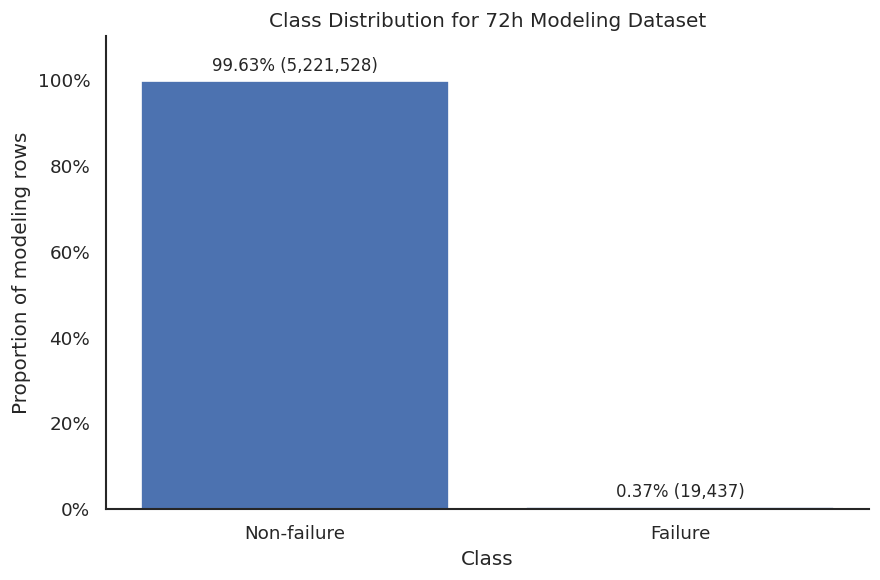

25

In [18]:
report_experiment_config = get_experiment_config(REPORT_EXPERIMENT_NAME)
report_modeling_df = build_experiment_dataset(master_df, report_experiment_config).copy()

class_balance_df = (
    report_modeling_df["target"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("target")
    .reset_index(name="count")
)
class_balance_df["class_name"] = class_balance_df["target"].map({0: "Non-failure", 1: "Failure"})
class_balance_df["percent"] = class_balance_df["count"] / class_balance_df["count"].sum()

display(class_balance_df[["class_name", "count", "percent"]])

fig_3_path = REPORT_FIG_DIR / "fig_3_class_imbalance_distribution.png"

fig, ax = plt.subplots(figsize=(7.5, 5))

bars = ax.bar(class_balance_df["class_name"], class_balance_df["percent"])

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(f"Class Distribution for {prettify_experiment_name(REPORT_EXPERIMENT_NAME)} Modeling Dataset")
ax.set_xlabel("Class")
ax.set_ylabel("Proportion of modeling rows")
ax.set_ylim(0, 1.1)

y_offset = class_balance_df["percent"].max() * 0.015

for bar, row in zip(bars, class_balance_df.itertuples(index=False)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + y_offset,
        f"{row.percent:.2%} ({int(row.count):,})",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

if SAVE_REPORT_FIGURES:
    fig.savefig(fig_3_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 3", "path": str(fig_3_path)})
    print(f"Saved figure to: {fig_3_path}")

plt.show()
plt.close(fig)

# The class-balance counts are all later cells need; release the full modeling copy.
del report_modeling_df
gc.collect()


## Figure 4: Model Performance Comparison Table

This table compares Logistic Regression, Random Forest, and XGBoost on the representative 72h prediction horizon.

Precision, recall, and F1 are reported on the holdout test set. These metrics are more informative than accuracy because the positive class is rare and operationally important.


,Model,Precision,Recall,F1
0,Random Forest,0.009840,0.019680,0.013120
1,XGBoost,0.006696,0.019680,0.009992
2,Logistic Regression,0.003330,0.273211,0.006581


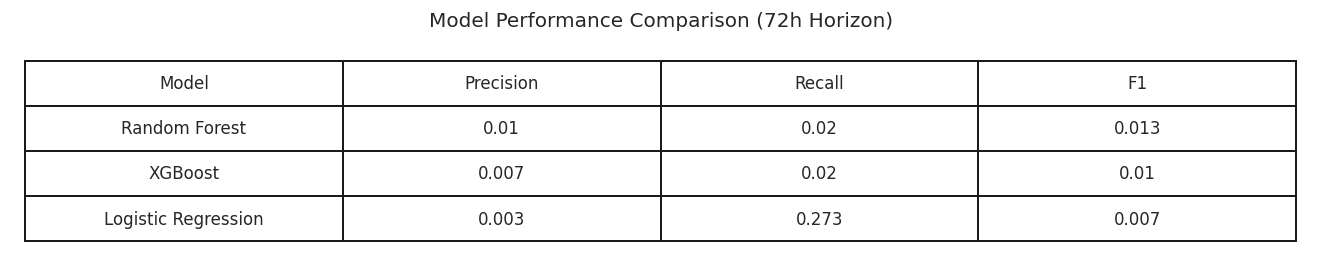

Saved table figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_4_model_performance_comparison_table.png
Saved table data to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_4_model_performance_comparison_table.csv


In [19]:
results_72h_df = experiment_bundles[REPORT_EXPERIMENT_NAME]["results_df"].copy()

model_table_df = (
    results_72h_df.loc[:, ["model_name", "test_precision", "test_recall", "test_f1"]]
    .rename(
        columns={
            "model_name": "Model",
            "test_precision": "Precision",
            "test_recall": "Recall",
            "test_f1": "F1",
        }
    )
)
model_table_df["Model"] = model_table_df["Model"].map(prettify_model_name)
model_table_df = model_table_df.sort_values("F1", ascending=False).reset_index(drop=True)

display(model_table_df)

fig_4_path = REPORT_FIG_DIR / "fig_4_model_performance_comparison_table.png"
fig_4_csv_path = REPORT_FIG_DIR / "fig_4_model_performance_comparison_table.csv"

if SAVE_REPORT_FIGURES:
    save_table_figure(
        model_table_df,
        title=f"Model Performance Comparison ({prettify_experiment_name(REPORT_EXPERIMENT_NAME)} Horizon)",
        output_path=fig_4_path,
        index=False,
        figsize=(11.5, 2.6),
    )
    save_dataframe_csv(model_table_df, fig_4_csv_path)
    report_asset_records.append({"asset": "Figure 4", "path": str(fig_4_path)})
    report_asset_records.append({"asset": "Figure 4 data", "path": str(fig_4_csv_path)})

## Figure 5: Prediction Window Comparison Table

This table isolates XGBoost and compares its test-set performance across the 24h, 48h, and 72h prediction horizons.

The goal is to determine whether the model is learning a narrow signal tied to a specific failure boundary or a broader degradation pattern distributed over time.


,Window,Precision,Recall,F1
0,24h,0.000939,0.004864,0.001575
1,48h,0.002485,0.008336,0.003829
2,72h,0.006696,0.019680,0.009992


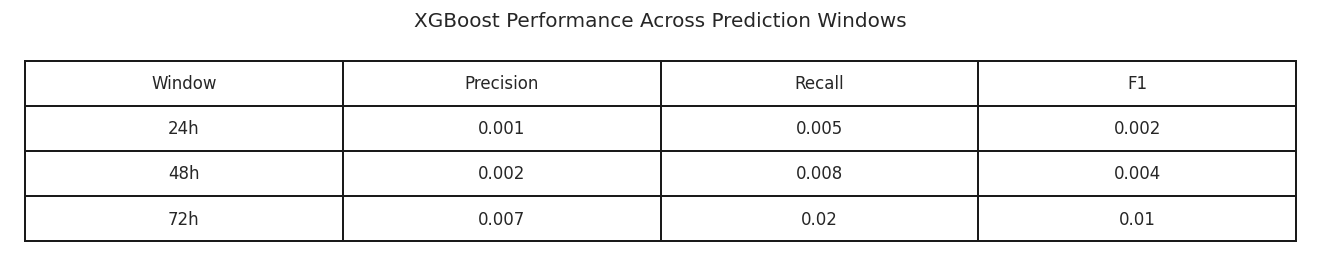

Saved table figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_5_prediction_window_comparison_table.png
Saved table data to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_5_prediction_window_comparison_table.csv


In [20]:
xgb_rows = []

for experiment_name, bundle in experiment_bundles.items():
    results_df = bundle["results_df"].copy()
    if REPORT_MODEL_NAME not in set(results_df["model_name"]):
        continue

    row = get_result_row(results_df, REPORT_MODEL_NAME)
    xgb_rows.append(
        {
            "Window": prettify_experiment_name(experiment_name),
            "Precision": row["test_precision"],
            "Recall": row["test_recall"],
            "F1": row["test_f1"],
        }
    )

xgb_window_table_df = pd.DataFrame(xgb_rows).sort_values("Window").reset_index(drop=True)
display(xgb_window_table_df)

fig_5_path = REPORT_FIG_DIR / "fig_5_prediction_window_comparison_table.png"
fig_5_csv_path = REPORT_FIG_DIR / "fig_5_prediction_window_comparison_table.csv"

if SAVE_REPORT_FIGURES:
    save_table_figure(
        xgb_window_table_df,
        title="XGBoost Performance Across Prediction Windows",
        output_path=fig_5_path,
        index=False,
        figsize=(11.5, 2.6),
    )
    save_dataframe_csv(xgb_window_table_df, fig_5_csv_path)
    report_asset_records.append({"asset": "Figure 5", "path": str(fig_5_path)})
    report_asset_records.append({"asset": "Figure 5 data", "path": str(fig_5_csv_path)})

## Prepare report diagnostics for threshold and temporal analysis

Saved experiment-level summaries are sufficient for model and horizon comparisons. However, the threshold sweep and temporal prediction timeline require row-level predicted probabilities.

The diagnostic helper below rebuilds or loads a lightweight set of row-level outputs for the representative XGBoost 72h experiment so those plots can be generated consistently.


In [21]:
def get_report_diagnostics(
    master_df: pd.DataFrame,
    experiment_name: str = REPORT_EXPERIMENT_NAME,
    model_name: str = REPORT_MODEL_NAME,
    force_rebuild: bool = FORCE_REBUILD_REPORT_DIAGNOSTICS,
) -> dict[str, Any]:
    """Load cached report diagnostics or build them with one fresh model run."""
    diag_dir = REPORT_DIAGNOSTICS_DIR / experiment_name / model_name
    diag_dir.mkdir(parents=True, exist_ok=True)

    predictions_path = diag_dir / "test_predictions.parquet"
    validation_threshold_path = diag_dir / "validation_threshold_sweep.csv"
    feature_importance_path = diag_dir / "feature_importance.csv"
    metadata_path = diag_dir / "diagnostic_metadata.json"

    if (
        not force_rebuild
        and predictions_path.exists()
        and validation_threshold_path.exists()
        and feature_importance_path.exists()
        and metadata_path.exists()
    ):
        return {
            "source": "cached_report_diagnostics",
            "test_predictions_df": pd.read_parquet(predictions_path),
            "validation_threshold_df": pd.read_csv(validation_threshold_path),
            "feature_importance_df": pd.read_csv(feature_importance_path),
            "metadata": json.loads(metadata_path.read_text()),
        }

    fresh_bundle = run_experiment_fresh(
        master_df=master_df,
        experiment_name=experiment_name,
        artifact_root=ARTIFACT_ROOT,
        model_names_override=[model_name],
        numeric_only=NUMERIC_ONLY,
        feature_subset=FEATURE_SUBSET,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        save_outputs=False,
        keep_full_objects=True,
    )

    trainer = fresh_bundle["detailed_results"][model_name]["trainer"]
    val_df = fresh_bundle["val_df"].copy()
    test_df = fresh_bundle["test_df"].copy()

    X_val = build_feature_matrix(val_df, numeric_only=NUMERIC_ONLY, feature_subset=FEATURE_SUBSET)
    y_val = val_df["target"].copy()

    X_test = build_feature_matrix(test_df, numeric_only=NUMERIC_ONLY, feature_subset=FEATURE_SUBSET)

    validation_threshold_df = build_threshold_sweep_table(
        y_true=y_val,
        y_prob=trainer.predict_proba(X_val),
    )

    test_predictions_df = test_df.copy()
    test_predictions_df["predicted_probability"] = trainer.predict_proba(X_test)
    test_predictions_df["predicted_label"] = (
        test_predictions_df["predicted_probability"] >= float(trainer.best_threshold)
    ).astype(int)

    feature_importance_df = trainer.get_feature_importance(
        fresh_bundle["feature_summary"]["selected_features"]
    ).copy()

    metadata = {
        "experiment_name": experiment_name,
        "model_name": model_name,
        "best_threshold": float(trainer.best_threshold),
        "source": "fresh_report_run",
        "n_val_rows": int(len(val_df)),
        "n_test_rows": int(len(test_df)),
    }

    test_predictions_df.to_parquet(predictions_path, index=False)
    validation_threshold_df.to_csv(validation_threshold_path, index=False)
    feature_importance_df.to_csv(feature_importance_path, index=False)
    metadata_path.write_text(json.dumps(metadata, indent=2))

    diagnostics = {
        "source": "fresh_report_run",
        "test_predictions_df": test_predictions_df,
        "validation_threshold_df": validation_threshold_df,
        "feature_importance_df": feature_importance_df,
        "metadata": metadata,
    }

    # Release large temporary training objects from the diagnostic-only run.
    del fresh_bundle, trainer, val_df, test_df
    del X_val, X_test, y_val
    release_notebook_memory()

    return diagnostics


report_diag = get_report_diagnostics(master_df=master_df)
print("Report diagnostic source:", report_diag["source"])
display(pd.DataFrame([report_diag["metadata"]]))


2026-04-15 17:13:49 | INFO | wtfd.models.experiments | Retrieved experiment config 'pre_72h' | models=['logistic', 'rf', 'xgboost'] | optimize_for=f1 | split_method=event_chronological
2026-04-15 17:13:50 | INFO | wtfd.models.splitter | Creating experiment target from canonical states | positive_states=[1, 2, 3] | buffer_state=5
2026-04-15 17:13:51 | INFO | wtfd.models.splitter | Created binary target column 'target' | positive_rows=19437 | negative_rows=5221528 | missing_rows=1983
2026-04-15 17:13:52 | INFO | wtfd.models.splitter | Initialized WindFarmSplitter with n_splits=5, random_state=42
2026-04-15 17:13:52 | INFO | wtfd.models.splitter | Creating event-level time split using event_id_col=event_id with train=0.70, val=0.15, test=0.15 on 5240965 rows
2026-04-15 17:13:53 | INFO | wtfd.models.splitter | Event-level time split created | train_events=66 | val_events=14 | test_events=15 | train_rows=3653092 | val_rows=761987 | test_rows=825886
2026-04-15 17:13:53 | INFO | wtfd.models.f

Report diagnostic source: fresh_report_run


,experiment_name,model_name,best_threshold,source,n_val_rows,n_test_rows
0,pre_72h,xgboost,0.8,fresh_report_run,761987,825886


## Figure 6: Threshold Sweep Curve

This plot shows how precision, recall, and F1 change as the classification threshold varies on the validation set.

The tuned threshold is highlighted because the default 0.5 cutoff is not necessarily appropriate for an imbalanced predictive-maintenance problem. In this project, threshold optimization is part of the evaluation strategy rather than an afterthought.


,threshold,precision,recall,f1,balanced_accuracy,specificity,false_positive_rate,false_negative_rate,tp,fp,tn,fn,support_positive,support_negative,roc_auc,pr_auc
43,0.80,0.044813,0.308796,0.078268,0.645043,0.981289,0.018711,0.691204,667,14217,745610,1493,2160,759827,0.800417,0.025052
42,0.78,0.044079,0.345833,0.078191,0.662256,0.978679,0.021321,0.654167,747,16200,743627,1413,2160,759827,0.800417,0.025052
44,0.82,0.045189,0.265278,0.077224,0.624672,0.984066,0.015934,0.734722,573,12107,747720,1587,2160,759827,0.800417,0.025052
45,0.84,0.046590,0.223611,0.077113,0.605301,0.986992,0.013008,0.776389,483,9884,749943,1677,2160,759827,0.800417,0.025052
41,0.76,0.042634,0.381019,0.076687,0.678348,0.975677,0.024323,0.618981,823,18481,741346,1337,2160,759827,0.800417,0.025052
40,0.75,0.041511,0.392130,0.075075,0.683195,0.974261,0.025739,0.607870,847,19557,740270,1313,2160,759827,0.800417,0.025052
39,0.74,0.040244,0.400463,0.073138,0.686657,0.972850,0.027150,0.599537,865,20629,739198,1295,2160,759827,0.800417,0.025052
46,0.86,0.045856,0.168056,0.072052,0.579058,0.990060,0.009940,0.831944,363,7553,752274,1797,2160,759827,0.800417,0.025052
38,0.72,0.037748,0.419907,0.069268,0.694739,0.969571,0.030429,0.580093,907,23121,736706,1253,2160,759827,0.800417,0.025052
37,0.70,0.035761,0.440741,0.066155,0.703479,0.966217,0.033783,0.559259,952,25669,734158,1208,2160,759827,0.800417,0.025052


Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_6_threshold_sweep_curve.png


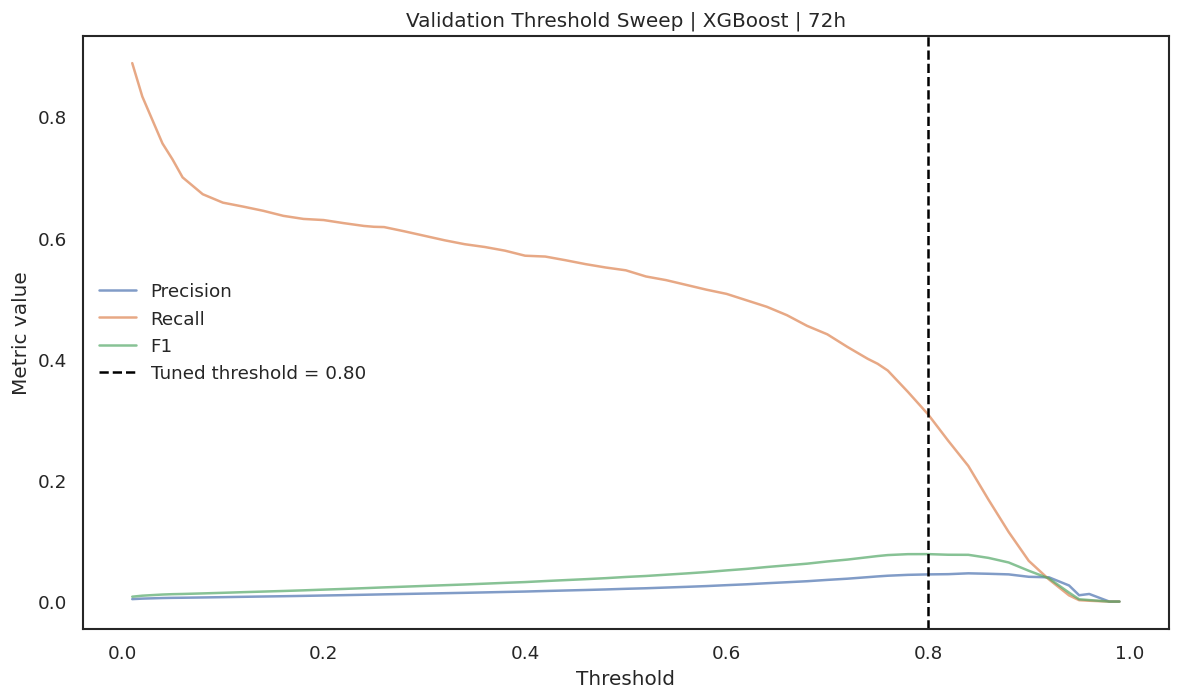

In [22]:
validation_threshold_df = report_diag["validation_threshold_df"].copy()
best_threshold = report_diag["metadata"]["best_threshold"]

display(
    validation_threshold_df.sort_values(
        by=["f1", "recall", "precision"],
        ascending=[False, False, False],
    ).head(15)
)

fig_6_path = REPORT_FIG_DIR / "fig_6_threshold_sweep_curve.png"

plt.figure(figsize=(10, 6))
plt.plot(validation_threshold_df["threshold"], validation_threshold_df["precision"], label="Precision", linewidth=1.5, alpha=0.7)
plt.plot(validation_threshold_df["threshold"], validation_threshold_df["recall"], label="Recall", linewidth=1.5, alpha=0.7)
plt.plot(validation_threshold_df["threshold"], validation_threshold_df["f1"], label="F1", linewidth=1.5, alpha=0.7)
plt.axvline(best_threshold, linestyle="--", color="black", linewidth=1.5, label=f"Tuned threshold = {best_threshold:.2f}")
plt.title(f"Validation Threshold Sweep | {prettify_model_name(REPORT_MODEL_NAME)} | {prettify_experiment_name(REPORT_EXPERIMENT_NAME)}")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.legend(frameon=False)
plt.tight_layout()
if SAVE_REPORT_FIGURES:
    plt.savefig(fig_6_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 6", "path": str(fig_6_path)})
    print(f"Saved figure to: {fig_6_path}")
plt.show()
plt.close()

## Figure 7: Temporal Prediction Timeline

This figure plots predicted failure probability over time around a representative event. It is designed to show whether model outputs have temporal structure rather than appearing as isolated random spikes.

A useful predictive-maintenance model should raise probabilities before or around failure-relevant periods, reflecting sustained degradation behavior in the SCADA signals.


/tmp/ipykernel_805/4127561210.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  timeline_predictions_df.dropna(subset=["event_start"])


,farm_id,asset_id,event_id,event_label,event_start,n_rows,n_positive,max_probability,mean_probability
0,A,0,26,anomaly,2023-10-12 10:20:00,53654,432,0.990597,0.244871
1,C,16,30,anomaly,2023-12-15 00:00:00,56063,432,0.794283,0.106485
2,C,53,16,anomaly,2023-12-23 00:00:00,53520,432,0.996346,0.098969
3,C,52,39,anomaly,2023-10-19 13:00:00,53679,432,0.991411,0.090597
4,C,43,11,anomaly,2023-10-17 12:30:00,56389,432,0.992809,0.085292
5,C,21,47,anomaly,2023-12-22 15:00:00,53945,432,0.750341,0.074494
6,C,38,81,anomaly,2023-11-16 01:30:00,53884,432,0.857533,0.042250
7,C,50,55,anomaly,2023-10-29 11:30:00,55705,432,0.291059,0.006930
8,C,23,70,anomaly,2023-11-10 14:00:00,55990,432,0.219394,0.006869
9,B,6,53,anomaly,2023-12-26 16:40:00,58583,431,0.925489,0.064931


Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_7_temporal_prediction_timeline.png


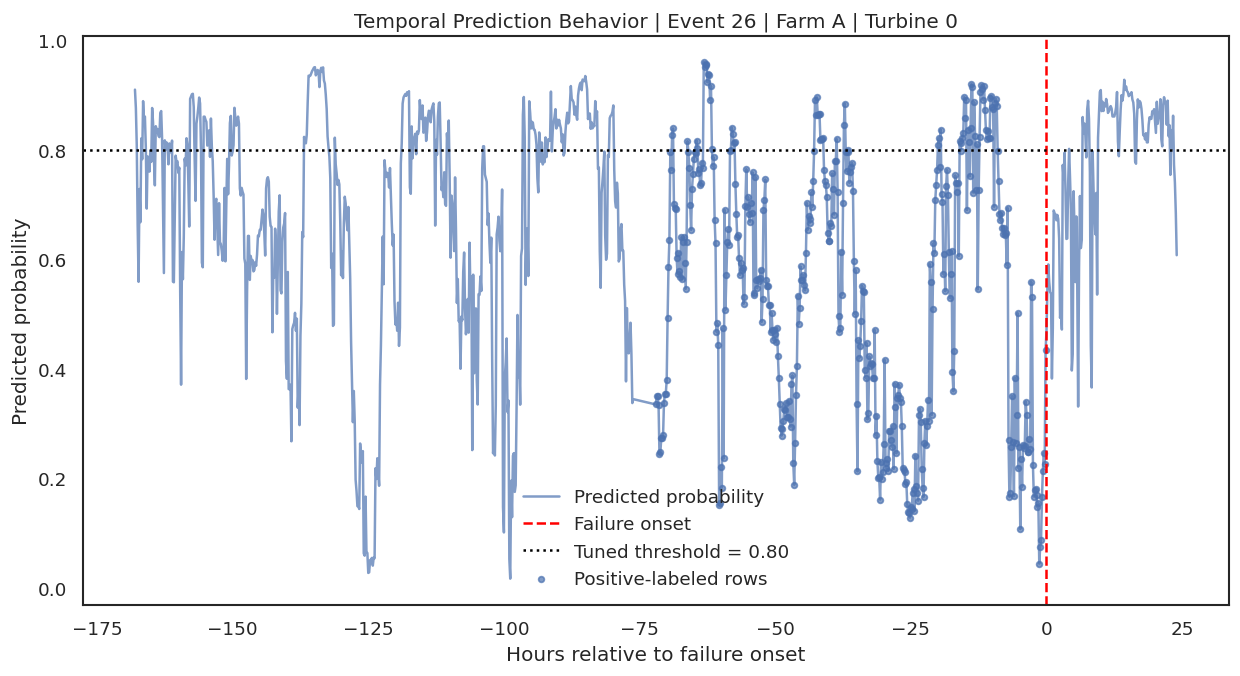

,time_stamp,hours_from_event_start,predicted_probability,target,state_name
485879,2023-10-05 10:20:00,-168.000000,0.910484,0,normal
485880,2023-10-05 10:30:00,-167.833333,0.877196,0,normal
485881,2023-10-05 10:40:00,-167.666667,0.807985,0,normal
485882,2023-10-05 10:50:00,-167.500000,0.661820,0,normal
485883,2023-10-05 11:00:00,-167.333333,0.559418,0,normal
485884,2023-10-05 11:10:00,-167.166667,0.728985,0,normal
485885,2023-10-05 11:20:00,-167.000000,0.668354,0,normal
485886,2023-10-05 11:30:00,-166.833333,0.821520,0,normal
485887,2023-10-05 11:40:00,-166.666667,0.783334,0,normal
485888,2023-10-05 11:50:00,-166.500000,0.889476,0,normal


4712

In [23]:
timeline_predictions_df = report_diag["test_predictions_df"].copy()

for dt_col in ["time_stamp", "event_start", "event_end"]:
    if dt_col in timeline_predictions_df.columns:
        timeline_predictions_df[dt_col] = pd.to_datetime(timeline_predictions_df[dt_col], errors="coerce")

group_cols = [c for c in ["farm_id", "asset_id", "event_id", "event_label", "event_start"] if c in timeline_predictions_df.columns]

if not group_cols:
    raise KeyError(
        "The prediction timeline requires event metadata columns such as "
        "'farm_id', 'asset_id', 'event_id', and 'event_start'."
    )

event_summary_df = (
    timeline_predictions_df.dropna(subset=["event_start"])
    .groupby(group_cols, dropna=False)
    .agg(
        n_rows=("predicted_probability", "size"),
        n_positive=("target", "sum"),
        max_probability=("predicted_probability", "max"),
        mean_probability=("predicted_probability", "mean"),
    )
    .reset_index()
)

positive_event_summary_df = event_summary_df.loc[event_summary_df["n_positive"] > 0].copy()
if positive_event_summary_df.empty:
    positive_event_summary_df = event_summary_df.copy()

# Choose a representative event with actual positive-labeled rows, then prefer
# stronger model response within that subset. This is more defensible than
# selecting solely on the single highest peak probability.
positive_event_summary_df = positive_event_summary_df.sort_values(
    by=["n_positive", "mean_probability", "max_probability", "event_start"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

display(positive_event_summary_df.head(10))

selected_event = positive_event_summary_df.iloc[0].to_dict()

mask = pd.Series(True, index=timeline_predictions_df.index)
for col in group_cols:
    value = selected_event[col]
    if pd.isna(value):
        mask &= timeline_predictions_df[col].isna()
    else:
        mask &= timeline_predictions_df[col] == value

selected_timeline_df = timeline_predictions_df.loc[mask].copy().sort_values("time_stamp")

selected_event_start = pd.to_datetime(selected_event["event_start"])
selected_timeline_df["hours_from_event_start"] = (
    (selected_timeline_df["time_stamp"] - selected_event_start).dt.total_seconds() / 3600.0
)

selected_timeline_df = selected_timeline_df[
    (selected_timeline_df["hours_from_event_start"] >= -TIMELINE_HOURS_BEFORE)
    & (selected_timeline_df["hours_from_event_start"] <= TIMELINE_HOURS_AFTER)
].copy()

fig_7_path = REPORT_FIG_DIR / "fig_7_temporal_prediction_timeline.png"

plt.figure(figsize=(10.5, 5.8))
plt.plot(
    selected_timeline_df["hours_from_event_start"],
    selected_timeline_df["predicted_probability"],
    linewidth=1.5,
    alpha=0.7,
    label="Predicted probability",
)
plt.axvline(0, linestyle="--", color="red", linewidth=1.5, label="Failure onset")
plt.axhline(best_threshold, linestyle=":", color="black", linewidth=1.5, label=f"Tuned threshold = {best_threshold:.2f}")

positive_rows_df = selected_timeline_df.loc[selected_timeline_df["target"] == 1]
if not positive_rows_df.empty:
    plt.scatter(
        positive_rows_df["hours_from_event_start"],
        positive_rows_df["predicted_probability"],
        s=12,
        alpha=0.7, 
        label="Positive-labeled rows",
    )

event_label_text = selected_event.get("event_label", "unknown")
farm_text = selected_event.get("farm_id", "unknown")
asset_text = selected_event.get("asset_id", "unknown")
event_id_text = selected_event.get("event_id", "unknown")

plt.title(
    f"Temporal Prediction Behavior | Event {event_id_text} | Farm {farm_text} | Turbine {asset_text}"
)
plt.xlabel("Hours relative to failure onset")
plt.ylabel("Predicted probability")
plt.legend(frameon=False)
plt.tight_layout()

if SAVE_REPORT_FIGURES:
    plt.savefig(fig_7_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 7", "path": str(fig_7_path)})
    print(f"Saved figure to: {fig_7_path}")

plt.show()
plt.close()

display(
    selected_timeline_df.loc[
        :,
        ["time_stamp", "hours_from_event_start", "predicted_probability", "target", "state_name"]
        if "state_name" in selected_timeline_df.columns
        else ["time_stamp", "hours_from_event_start", "predicted_probability", "target"]
    ].head(25)
)

# The selected event slice has been created and plotted; release the full test-prediction table.
report_diag["test_predictions_df"] = None
del timeline_predictions_df, event_summary_df, positive_event_summary_df
gc.collect()


## Figure 8: Feature Importance Plot

The final core report figure summarizes the most influential XGBoost features for the representative 72h horizon.

Feature importance is used here as an interpretability check. Physically meaningful variables such as vibration, temperature, wind speed, power efficiency, and operational instability support the claim that the model is capturing plausible turbine behavior rather than arbitrary correlations.


,feature,importance
0,vibration_raw,0.062646
1,amb_temp,0.055810
2,nacelle_temp,0.054049
3,vibration_magnitude,0.051794
4,hydraulic_temp,0.051221
5,pitch_angle,0.051049
6,hub_temp,0.044993
7,wind_speed,0.042398
8,transformer_temp,0.041180
9,power_efficiency,0.037742


Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project_Copy/outputs/final_report_figures/fig_8_feature_importance_plot.png


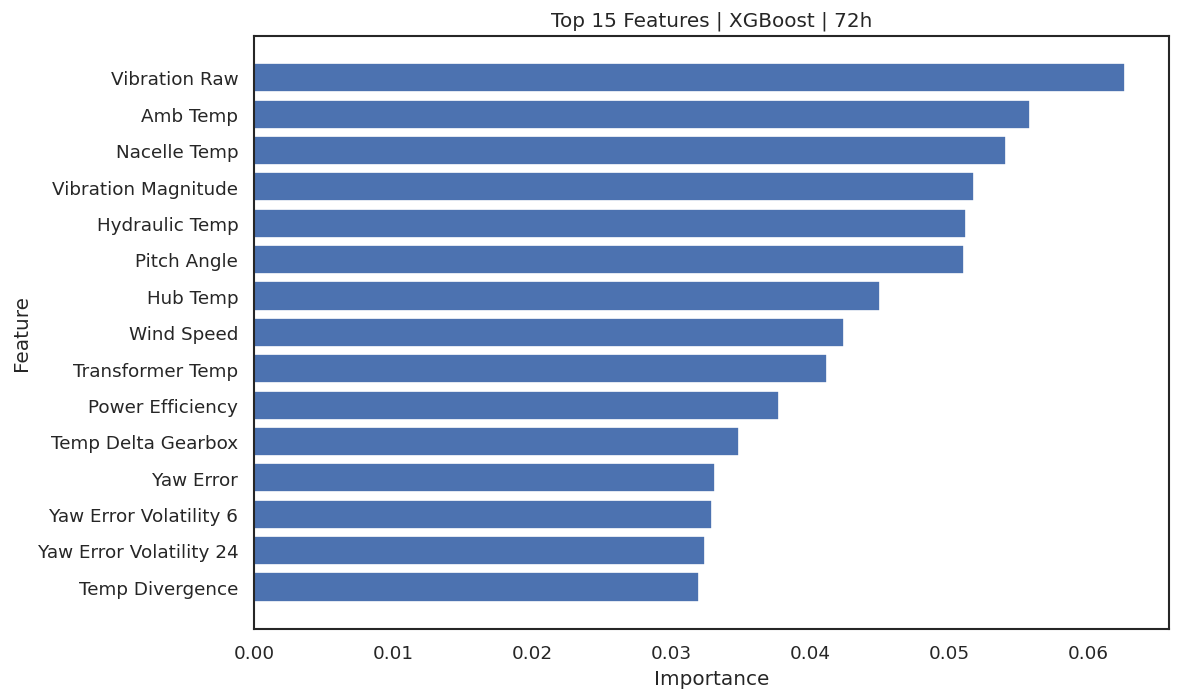

In [24]:
importance_df = report_diag["feature_importance_df"].copy()

value_col = "importance" if "importance" in importance_df.columns else "coefficient"
plot_importance_df = (
    importance_df
    .sort_values(value_col, ascending=False)
    .head(TOP_N_FEATURES)
    .iloc[::-1]
    .copy()
)
plot_importance_df["feature_display"] = plot_importance_df["feature"].map(clean_feature_name)

display(plot_importance_df.loc[:, ["feature", value_col]].sort_values(value_col, ascending=False))

fig_8_path = REPORT_FIG_DIR / "fig_8_feature_importance_plot.png"

plt.figure(figsize=(10, max(6, 0.35 * len(plot_importance_df))))
plt.barh(plot_importance_df["feature_display"], plot_importance_df[value_col])
plt.title(
    f"Top {TOP_N_FEATURES} Features | {prettify_model_name(REPORT_MODEL_NAME)} | "
    f"{prettify_experiment_name(REPORT_EXPERIMENT_NAME)}"
)
plt.xlabel("Importance" if value_col == "importance" else "Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

if SAVE_REPORT_FIGURES:
    plt.savefig(fig_8_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 8", "path": str(fig_8_path)})
    print(f"Saved figure to: {fig_8_path}")

plt.show()
plt.close()

## Report Outputs

The table below lists the saved figures and table exports generated by the notebook. These outputs are intended for direct insertion into the written report.

In [25]:
report_asset_manifest_df = (
    pd.DataFrame(report_asset_records)
    .drop_duplicates()
    .sort_values("asset")
    .reset_index(drop=True)
)
display(report_asset_manifest_df)

,asset,path
0,Figure 1,/mnt/c/grad_school/northeastern/courses/ie7275...
1,Figure 2,/mnt/c/grad_school/northeastern/courses/ie7275...
2,Figure 2 data,/mnt/c/grad_school/northeastern/courses/ie7275...
3,Figure 3,/mnt/c/grad_school/northeastern/courses/ie7275...
4,Figure 4,/mnt/c/grad_school/northeastern/courses/ie7275...
5,Figure 4 data,/mnt/c/grad_school/northeastern/courses/ie7275...
6,Figure 5,/mnt/c/grad_school/northeastern/courses/ie7275...
7,Figure 5 data,/mnt/c/grad_school/northeastern/courses/ie7275...
8,Figure 6,/mnt/c/grad_school/northeastern/courses/ie7275...
9,Figure 7,/mnt/c/grad_school/northeastern/courses/ie7275...


## Summary

This notebook provides a single, reproducible implementation of the wind turbine fault detection workflow required for the final project submission.

It demonstrates the full pipeline: validating project inputs, preprocessing and harmonizing SCADA data, engineering temporal degradation features, applying event-based labels, training multiple supervised models, tuning decision thresholds, evaluating performance under class imbalance, and saving report-ready outputs.

The results support the central interpretation developed in the final report: wind turbine failure prediction is best treated as an early-warning degradation problem rather than an exact failure-time prediction task. The modest absolute metrics should be interpreted in the context of rare events, noisy operational data, and the practical tradeoff between missed failures and false alarms.


## References

Kasimov, A. (2024). *Wind turbine SCADA data for early fault detection* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.10958775

## Cleanup

The final cell releases large in-memory objects created during notebook execution. This step is optional, but it is helpful after a full run on the complete processed dataset.


In [26]:
for var_name in [
    "sample_df",
    "master_df",
    "report_modeling_df",
    "timeline_predictions_df",
    "selected_timeline_df",
]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()
print("Cleanup complete.")


Cleanup complete.
